# 空间转录组-单细胞联合分析脚本说明文档
## 概述
```
在生物学研究中，组织通常是由多种不同类型的细胞混合组成的复杂系统。传统的转录组测序技术对组织样本进行整体测序，得到的是所有细胞转录信息的混合结果，无法区分不同细胞类型的表达特征。而单细胞 RNA 测序（scRNA - seq）技术虽然能够提供单个细胞水平的转录组信息，但它通常需要将组织解离成单细胞悬液，这可能会破坏细胞间的相互作用和组织微环境信息。
空间转录组学技术的出现，使得在保留组织空间结构的前提下，对基因表达进行测量成为可能。然而，空间转录组数据往往是基于组织切片的，每个空间位点可能包含多个不同类型的细胞，因此需要一种方法来解析每个空间位点中不同细胞类型的组成比例。随机卷积转录解卷积（Random Convolutional Transcriptomic Deconvolution，RCTD）算法就是为解决这一问题而开发的。
RCTD 的核心目标是利用单细胞 RNA 测序数据作为参考，对空间转录组数据进行细胞类型解卷积，即推断每个空间位点中不同细胞类型的比例。RCTD 使用随机卷积模型来模拟空间转录组数据中每个位点的基因表达。该模型假设每个空间位点的基因表达是由不同细胞类型的表达谱经过随机卷积得到的。具体来说，对于每个空间位点，模型会随机选择一定数量的不同细胞类型的细胞，并按照一定的比例将它们的表达谱进行加权求和，得到该位点的模拟表达谱。通过多次随机卷积，可以生成大量的模拟表达谱，这些模拟表达谱构成了一个表达谱的分布。对于每个空间位点的实际基因表达谱，RCTD 会在随机卷积生成的表达谱分布中寻找最匹配的组合。通过最大似然估计的方法，计算该位点中不同细胞类型的最优比例，使得实际表达谱与模拟表达谱之间的似然度最大。最终，RCTD 会输出每个空间位点中不同细胞类型的比例，以及每个位点的细胞类型组成情况。
```
## 数据准备
### 格式如下
```
1.单细胞表达量矩阵文件
        cell1	  cell2	  cell3	  ......	celln
gene1	  0	        0	    0	  ......	1
gene2	  1	        0	    2	  ......	0
gene3	  0	        0	    1	  ......	0
......	......	......	......	  ......	......
genen	  1	        1	    0	  ......	0

2.单细胞注释文件
cell1	Elongating
cell2	Elongating
cell3	Elongating
......	......
celln	Myoid

3.空间矩阵文件

BSTViewer_project/subdata/L*_heAuto/
.
├── barcodes_pos.tsv.gz		barcode坐标文件	
├── barcodes.tsv.gz		barcode id 信息
├── features.tsv.gz		gene id信息
└── matrix.mtx.gz		表达量矩阵


## 环境配置
### 依赖包

In [1]:
suppressMessages({
  library(Seurat)
  library(spacexr)
  library(Matrix)
  library(dplyr)
  library(ggplot2)
  library(tibble)
  library(Rcpp)
  library(ggsci)
})


Warning message:
“package ‘tibble’ was built under R version 4.2.1”
Warning message:
“package ‘Rcpp’ was built under R version 4.2.2”


### 参数配置

In [9]:
scmeta = "../sc_meta.txt"
anno = "../ref_cell_anno"
stmat = "./mtx/"
od = "./outdir"
number = 2
min_cells = 5
min_features = 100
point_size = 0.01

if(!dir.exists(od)){dir.create(path=od)}

### 具体脚本

In [3]:
######读取单细胞数据和功能注释结果
sc_counts<-read.table(scmeta,header = T,row.names = 1, check.names = F)
sc_nUMI = colSums(sc_counts)
##读取单细胞注释结果
cellType = read.table(file = anno,header = F,sep = "\t",check.names = F)
names(cellType) <- c("barcode","cell_type")


In [4]:
###提取细胞类型信息
cellType$cell_type<-as.factor(cellType$cell_type)
cellType<-cellType %>% filter(cell_type %in% names(table(cellType$cell_type)[table(cellType$cell_type)>25]))
cellType$cell_type=as.character(cellType$cell_type)

cell_types = cellType$cell_type
names(cell_types) <- cellType$barcode
cell_types = as.factor(cell_types)

sc_counts<-sc_counts[,which(colnames(sc_counts)%in%cellType$barcode)]

sc_nUMI<-sc_nUMI[cellType$barcode]
reference = Reference(sc_counts, cell_types, sc_nUMI)


Warning message in Reference(sc_counts, cell_types, sc_nUMI):
“Reference: number of cells per cell type is 60250, larger than maximum allowable of 10000. Downsampling number of cells to: 10000”


In [5]:
##########提取count矩阵
Rcpp::sourceCpp(code='
#include <Rcpp.h>
using namespace Rcpp;
// [[Rcpp::export]]
IntegerMatrix asMatrix(NumericVector rp,
                       NumericVector cp,
                       NumericVector z,
                       int nrows,
                       int ncols){
  int k = z.size() ;
  IntegerMatrix  mat(nrows, ncols);
  for (int i = 0; i < k; i++){
      mat(rp[i],cp[i]) = z[i];
  }
  return mat;
}
' )
as_matrix <- function(mat){
  row_pos <- mat@i
  col_pos <- findInterval(seq(mat@x)-1,mat@p[-1])
  tmp <- asMatrix(rp = row_pos, cp = col_pos, z = mat@x,
                  nrows =  mat@Dim[1], ncols = mat@Dim[2])
  row.names(tmp) <- mat@Dimnames[[1]]
  colnames(tmp) <- mat@Dimnames[[2]]
  return(tmp)
}

#读取空间数据
#位置信息
bc_pos_file = gzfile(paste(stmat, "barcodes_pos.tsv.gz", sep="/"),'rt')
coords = read.table(bc_pos_file, sep="\t", header = F) %>% 
  rename(barcodes = V1, xcoord = V2, ycoord = V3)
coords$ycoord = coords$ycoord*-1 
rownames(coords) <- coords$barcodes
coords$barcodes <- NULL

#表达量矩阵
expr <- Read10X(stmat, gene.column = number)
#初步过滤
sp_data <- CreateSeuratObject(counts = expr,assay = "Spatial",min.cells  = min_cells,min.features = min_features)
sp_counts <- as_matrix(sp_data[['Spatial']]@counts)
#nUMI
sp_nUMI <- colSums(sp_counts)
#构建空间实验集
puck <- SpatialRNA(coords, sp_counts, sp_nUMI)


Warning message in SpatialRNA(coords, sp_counts, sp_nUMI):
“SpatialRNA: some barcodes in nUMI, coords, or counts were not mutually shared. Such barcodes were removed.”


In [6]:
#联合分析
myRCTD <- create.RCTD(puck, reference, max_cores = 8,CELL_MIN_INSTANCE = 20)
myRCTD <- run.RCTD(myRCTD, doublet_mode = 'doublet') #run.RCTD 


Begin: process_cell_type_info

process_cell_type_info: number of cells in reference: 67916

process_cell_type_info: number of genes in reference: 28493




           BW         CD_IC         CD_PC      CD_Trans           DCT 
         1070         10000         10000          7536          5843 
          LOH Myofibroblast          Podo            PT       T_Lymph 
        10000          4753          4285         10000          4429 


Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 2.1 GiB”
Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 2.1 GiB”
Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 1.6 GiB”
Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 1.2 GiB”
Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 2.1 GiB”
Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 1.0 GiB”
Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 2.1 GiB”
End: process_cell_type_info

create.RCTD: getting regression differentially expressed genes: 

get_de_genes: BW found DE genes: 74

get_de_genes: CD_IC found DE genes: 70

get_de_genes: CD_PC found DE genes: 179

get_de_genes: CD_Trans found DE genes: 40

get_de_genes: DCT found DE genes: 37

get_de_genes: LOH found DE 

[1] "gather_results: finished 1000"
[1] "gather_results: finished 2000"
[1] "gather_results: finished 3000"
[1] "gather_results: finished 4000"
[1] "gather_results: finished 5000"
[1] "gather_results: finished 6000"
[1] "gather_results: finished 7000"
[1] "gather_results: finished 8000"
[1] "gather_results: finished 9000"
[1] "gather_results: finished 10000"
[1] "gather_results: finished 11000"
[1] "gather_results: finished 12000"
[1] "gather_results: finished 13000"
[1] "gather_results: finished 14000"
[1] "gather_results: finished 15000"
[1] "gather_results: finished 16000"
[1] "gather_results: finished 17000"
[1] "gather_results: finished 18000"
[1] "gather_results: finished 19000"
[1] "gather_results: finished 20000"
[1] "gather_results: finished 21000"
[1] "gather_results: finished 22000"
[1] "gather_results: finished 23000"
[1] "gather_results: finished 24000"
[1] "gather_results: finished 25000"
[1] "gather_results: finished 26000"
[1] "gather_results: finished 27000"
[1] "gathe

In [10]:
#查找marker基因
get_marker_data <- function(cell_type_names, cell_type_means, gene_list) {
  marker_means = cell_type_means[gene_list,]
  marker_norm = marker_means / rowSums(marker_means)
  marker_data = as.data.frame(cell_type_names[max.col(marker_means)])
  marker_data$max_epr <- apply(cell_type_means[gene_list,],1,max)
  colnames(marker_data) = c("cell_type",'max_epr')
  rownames(marker_data) = gene_list
  marker_data$log_fc <- 0
  epsilon <- 1e-9
  for(cell_type in unique(marker_data$cell_type)) {
    cur_genes <- gene_list[marker_data$cell_type == cell_type]
    other_mean = rowMeans(cell_type_means[cur_genes,cell_type_names != cell_type])
    marker_data$log_fc[marker_data$cell_type == cell_type] <- log(epsilon + cell_type_means[cur_genes,cell_type]) - log(epsilon + other_mean)
  }
  return(marker_data)
}

cell_type_info_restr = myRCTD@cell_type_info$info
de_genes <- get_de_genes(cell_type_info_restr, puck, fc_thresh = 3, expr_thresh = .0001, MIN_OBS = 3)
marker_data_de = get_marker_data(cell_type_info_restr[[2]], cell_type_info_restr[[1]], de_genes)
marker_data_de %>% rownames_to_column(var = "Gene") -> marker_data_de2
write.table(marker_data_de2, file = paste0(od,'/marker_data_de_standard.tsv'), sep = '\t',quote = F, row.names = F)


get_de_genes: BW found DE genes: 18

get_de_genes: CD_IC found DE genes: 1

get_de_genes: CD_PC found DE genes: 0

get_de_genes: CD_Trans found DE genes: 3

get_de_genes: DCT found DE genes: 4

get_de_genes: LOH found DE genes: 0

get_de_genes: Myofibroblast found DE genes: 1

get_de_genes: Podo found DE genes: 16

get_de_genes: PT found DE genes: 0

get_de_genes: T_Lymph found DE genes: 20

get_de_genes: total DE genes: 63



In [12]:
#构建绘图数据
results_df <- myRCTD@results$results_df
barcodes = rownames(results_df[results_df$spot_class != "reject" & puck@nUMI >= 1,])
my_table = puck@coords[barcodes,]
my_table$class = results_df[barcodes,]$first_type
my_table %>% rownames_to_column(var = "barcode") -> my_table2
write.table(x = my_table2,file = paste0(od,"/my_table.xls"),append = F,
            quote = F,sep = "\t",row.names = F,col.names = T)


In [16]:
head(my_table)

,x,y,class
,<int>,<dbl>,<fct>
cell_1,2220,-36,PT
cell_79,2252,-87,PT
cell_133,2224,-145,PT
cell_215,2229,-212,PT
cell_42,2336,-35,PT
cell_68,2305,-58,PT


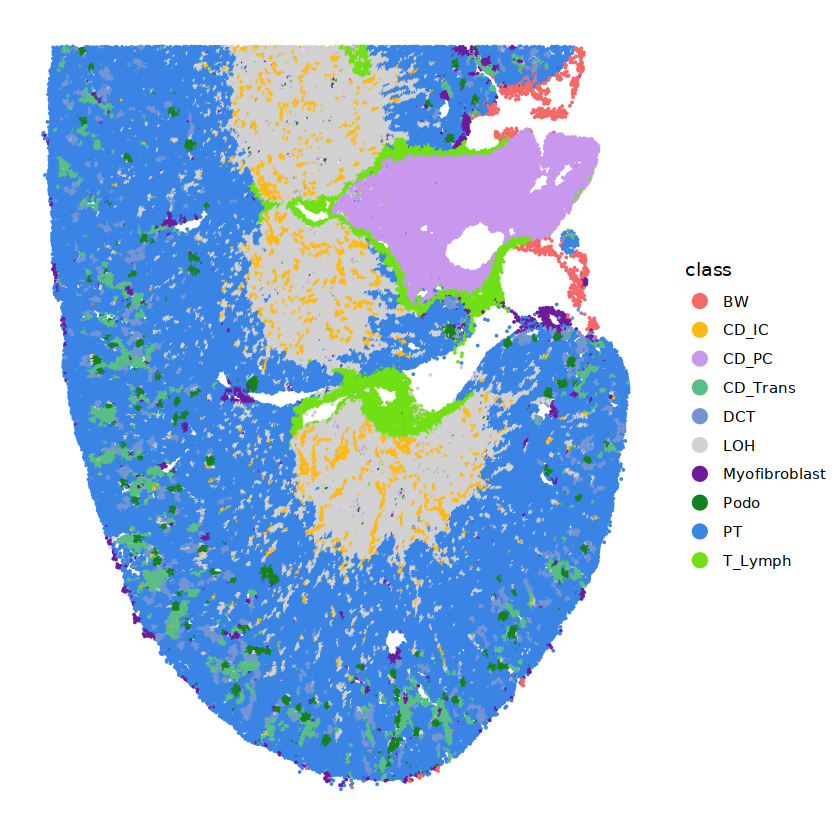

In [15]:
#######画图
mycol = c("#F56867","#FEB915","#C798EE","#59BE86","#7495D3","#D1D1D1","#6D1A9C","#15821E","#3A84E6",
          "#70e014","#787878","#DB4C6C","#0430e0","#554236","#AF5F3C","#ff7700","#e00417","#DAB370",
          "#fcfc05","#268785","#ed1299", "#09f9f5", "#246b93", "#cc8e12", "#d561dd", "#c93f00", 
          "#ddd53e","#4aef7b", "#e86502", "#9ed84e", "#39ba30", "#6ad157", "#8249aa", "#99db27",
          "#e07233", "#ff523f","#ce2523", "#f7aa5d", "#cebb10", "#03827f", "#931635", "#373bbf", 
          "#a1ce4c", "#ef3bb6", "#d66551","#1a918f", "#ff66fc", "#2927c4", "#7149af" ,"#57e559",
          "#8e3af4" ,"#f9a270" ,"#22547f", "#db5e92","#edd05e", "#6f25e8", "#0dbc21", "#280f7a", 
          "#6373ed", "#5b910f" ,"#7b34c1" ,"#0cf29a" ,"#d80fc1", "#51f59b")


p <- ggplot(data = my_table,aes(x = x,y = y,color = class)) + 
  geom_point(size = point_size,alpha = 1) +
  scale_colour_manual(values = mycol) +
  theme(panel.background = element_blank(),
        panel.grid = element_blank(),
        axis.title = element_blank(),
        axis.text = element_blank(),
        axis.ticks = element_blank(),
        legend.key = element_blank()) +
  guides(colour = guide_legend(override.aes = list(size=3.5))) 

p
ggsave(filename = paste0(od,"/anno.png"),width = 9,height = 7,plot = p,dpi = 300)
ggsave(filename = paste0(od,"/anno.pdf"),width = 9,height = 7,plot = p,dpi = 300)


In [14]:
saveRDS(object = myRCTD,file = paste0(od,"/RCTD.rds"))